# Chapter 12, Question 9 — Hierarchical Clustering on USArrests

**Task:** Cluster the 50 US states using hierarchical clustering with complete
linkage and Euclidean distance, first on the raw variables, then on the
variables after scaling each to unit variance, and compare the two results.

## Load the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree
from sklearn.preprocessing import StandardScaler

from statsmodels.datasets import get_rdataset
USArrests = get_rdataset('USArrests').data
USArrests.head()

,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


Four variables per state: `Murder`, `Assault`, and `Rape` are arrests per 100,000 residents; `UrbanPop` is the percentage of the population living in urban areas — a very different unit and scale from the other three, which matters a lot for part (d).

## (a) Hierarchical clustering, complete linkage, Euclidean distance, unscaled

`scipy`'s `linkage` function performs the clustering; `method='complete'` sets
the linkage criterion (cluster distance = the *maximum* pairwise distance
between members of the two clusters), and the default metric is Euclidean.

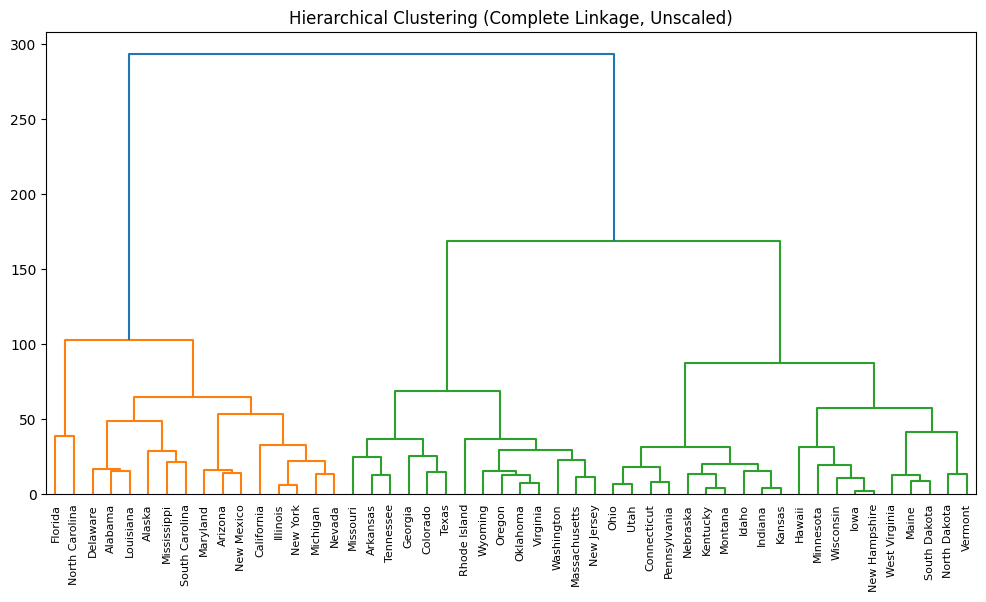

In [2]:
linkage_raw = linkage(USArrests, method='complete', metric='euclidean')

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(linkage_raw, labels=USArrests.index.to_list(), leaf_font_size=8, ax=ax)
ax.set_title('Hierarchical Clustering (Complete Linkage, Unscaled)')
plt.show()

## (b) Cut the tree to obtain 3 clusters

`cut_tree` cuts the dendrogram at whatever height produces exactly 3
branches, and returns each state's cluster assignment.

In [3]:
clusters_raw = cut_tree(linkage_raw, n_clusters=3).reshape(-1)
pd.Series(clusters_raw, index=USArrests.index, name='cluster').sort_values()

rownames
Alabama           0
Alaska            0
Arizona           0
California        0
Delaware          0
Florida           0
Illinois          0
Louisiana         0
Michigan          0
Nevada            0
New Mexico        0
New York          0
Maryland          0
Mississippi       0
South Carolina    0
North Carolina    0
New Jersey        1
Missouri          1
Colorado          1
Massachusetts     1
Oklahoma          1
Oregon            1
Wyoming           1
Virginia          1
Tennessee         1
Texas             1
Washington        1
Rhode Island      1
Georgia           1
Arkansas          1
Hawaii            2
Connecticut       2
New Hampshire     2
Nebraska          2
Montana           2
Minnesota         2
Maine             2
Kentucky          2
Iowa              2
Kansas            2
Idaho             2
Indiana           2
North Dakota      2
Pennsylvania      2
Utah              2
South Dakota      2
Vermont           2
Ohio              2
West Virginia     2
Wisconsin  

## (c) Repeat after scaling each variable to standard deviation 1

`StandardScaler` centers each column to mean 0 and scales it to standard
deviation 1, so no single variable dominates the distance calculation purely
because of its units.

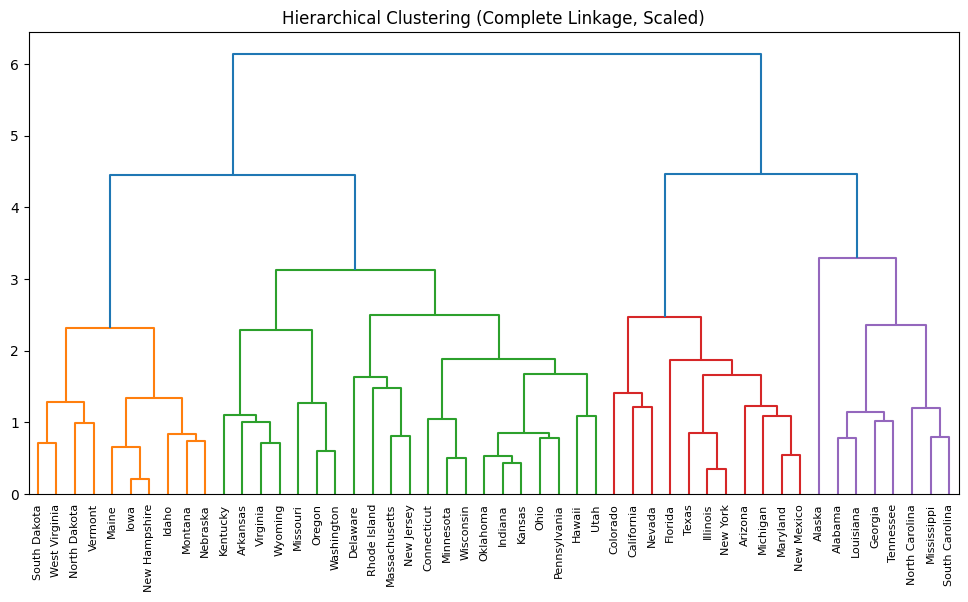

In [4]:
USArrests_scaled = StandardScaler().fit_transform(USArrests)

linkage_scaled = linkage(USArrests_scaled, method='complete', metric='euclidean')

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(linkage_scaled, labels=USArrests.index.to_list(), leaf_font_size=8, ax=ax)
ax.set_title('Hierarchical Clustering (Complete Linkage, Scaled)')
plt.show()

In [5]:
clusters_scaled = cut_tree(linkage_scaled, n_clusters=3).reshape(-1)
pd.Series(clusters_scaled, index=USArrests.index, name='cluster').sort_values()

rownames
Alabama           0
Alaska            0
Georgia           0
Louisiana         0
Mississippi       0
Tennessee         0
South Carolina    0
North Carolina    0
Maryland          1
Nevada            1
New Mexico        1
New York          1
Florida           1
Illinois          1
Colorado          1
Arizona           1
Texas             1
Michigan          1
California        1
Idaho             2
Kansas            2
Iowa              2
Indiana           2
Maine             2
Minnesota         2
Massachusetts     2
Kentucky          2
Missouri          2
Hawaii            2
Arkansas          2
Connecticut       2
Delaware          2
New Hampshire     2
New Jersey        2
Montana           2
Nebraska          2
Oklahoma          2
Oregon            2
Ohio              2
North Dakota      2
Rhode Island      2
Pennsylvania      2
South Dakota      2
Utah              2
Vermont           2
Virginia          2
Washington        2
West Virginia     2
Wisconsin         2
Wyoming    

## (d) Does scaling change the clusters? Should the variables be scaled first?

A cross-tabulation shows how the unscaled cluster assignments (rows) line up
against the scaled cluster assignments (columns). If scaling made no
difference, every row would have all its states concentrated in a single
column.

In [6]:
pd.crosstab(pd.Series(clusters_raw, name='Unscaled'),
            pd.Series(clusters_scaled, name='Scaled'))

Scaled,0,1,2
Unscaled,,,
0,6,9,1
1,2,2,10
2,0,0,20


In [7]:
USArrests.var()

Murder        18.970465
Assault     6945.165714
UrbanPop     209.518776
Rape          87.729159
dtype: float64

**Interpretation.** The cross-tabulation shows the two clusterings do not
line up cleanly — several states switch cluster membership once scaling is
applied, so scaling clearly changes the result here, not just cosmetically.

Looking at the variances explains why: `Assault` has a variance of roughly
6{,}945, while `Murder` has a variance of only about 19 — several hundred
times smaller. Euclidean distance is dominated by whichever variable has the
largest numeric spread, so on the unscaled data, clustering is effectively
driven almost entirely by `Assault`, with `Murder`, `UrbanPop`, and `Rape`
contributing very little to the distances despite being conceptually just as
important.

**Should the variables be scaled before clustering?** Yes, in this case.
`UrbanPop` is measured in a completely different unit (a percentage) than the
three crime-rate variables (arrests per 100,000 people), so there is no
natural sense in which their raw numeric scales should be treated as
comparable. Scaling first ensures every variable gets an equal say in the
distance calculation, which better reflects genuine similarity between
states across all four dimensions rather than similarity driven by whichever
variable happens to have the largest raw numbers.